# Exploratory Data Analysis

**Project:** Pokémon Type Prediction from Sprite Colors (XAI)

**Team:** Grifo Amarillo

This notebook explores the 42-feature color dataset extracted by `src/processer.py`.
Goals:
- Understand class imbalance and its severity
- Inspect feature distributions and correlations
- Visualize the feature space in 2D (PCA, t-SNE)
- Sanity-check that color features align with type intuitions

In [2]:
import json
import sys

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE


cwd = Path.cwd()
if (cwd / "src").is_dir():
    src_path = cwd / "src"
elif (cwd.parent / "src").is_dir():
    src_path = cwd.parent / "src"
else:
    raise FileNotFoundError("Could not find the 'src' directory. Check your working directory.")
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))
import common

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
PROJECT_ROOT = Path.cwd().parent
pokemon_path = PROJECT_ROOT / 'data' / 'raw' / 'pokemon.json'

with open(pokemon_path, 'r') as f:
    pokemon_data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(pokemon_data)

print(f"Shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))
print(f"\nData types:")
print(df.dtypes)
print(f"\nBasic stats:")
print(df.info())

Shape: (1025, 4)

First few rows:
         name  id  type1   type2
0   bulbasaur   1  grass  poison
1     ivysaur   2  grass  poison
2    venusaur   3  grass  poison
3  charmander   4   fire     NaN
4  charmeleon   5   fire     NaN
5   charizard   6   fire  flying
6    squirtle   7  water     NaN
7   wartortle   8  water     NaN
8   blastoise   9  water     NaN
9    caterpie  10    bug     NaN

Data types:
name       str
id       int64
type1      str
type2      str
dtype: object

Basic stats:
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    1025 non-null   str  
 1   id      1025 non-null   int64
 2   type1   1025 non-null   str  
 3   type2   526 non-null    str  
dtypes: int64(1), str(3)
memory usage: 32.2 KB
None


## 1. Type distribution (Type1)

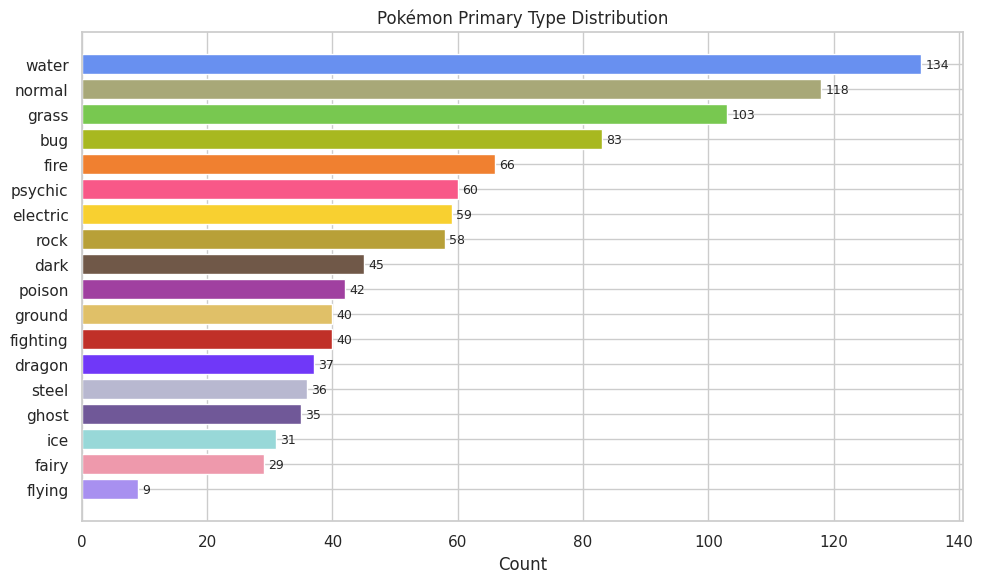


Largest class: water (134)
Smallest class: flying (9)
Imbalance ratio: 14.9x


In [3]:
counts = df["type1"].value_counts().sort_values()
colors = [common.TYPE_COLORS.get(t, "#888888") for t in counts.index]
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel("Count")
ax.set_title("Pokémon Primary Type Distribution")
plt.tight_layout()
plt.show()
print(f"\nLargest class: {counts.index[-1]} ({counts.values[-1]})")
print(f"Smallest class: {counts.index[0]} ({counts.values[0]})")
print(f"Imbalance ratio: {counts.values[-1]/counts.values[0]:.1f}x")

## 2. Flying Type Pokemon analysis

In [4]:
# Flying type analysis
flying_primary = df[df['type1'] == 'flying']
flying_secondary = df[df['type2'] == 'flying']
flying_pure = flying_primary[flying_primary['type2'].isna()]
flying_secondary_only = flying_secondary[flying_secondary['type1'] != 'flying']

print(f"Pokémon Voladores:\n")
print(f"  - Tipo primario volador (type1='flying'): {len(flying_primary)}")
print(f"    - Puros (solo volador): {len(flying_pure)}")
print(f"  - Tipo secundario volador (type2='flying'): {len(flying_secondary)}")
print(f"    - Solo secundario: {len(flying_secondary_only)}")
print(f"\nTotal con tipo volador: {len(flying_primary) + len(flying_secondary_only)}")

# Show the pure flying types
print(f"\nPokémon voladores PUROS (type1=flying, type2=null):")
print(flying_pure[['name', 'id', 'type1', 'type2']].to_string())

Pokémon Voladores:

  - Tipo primario volador (type1='flying'): 9
    - Puros (solo volador): 3
  - Tipo secundario volador (type2='flying'): 100
    - Solo secundario: 100

Total con tipo volador: 109

Pokémon voladores PUROS (type1=flying, type2=null):
                   name   id   type1 type2
640  tornadus-incarnate  641  flying   NaN
820            rookidee  821  flying   NaN
821         corvisquire  822  flying   NaN


In [5]:
# Flying with primary type
print(f"Pokémon con tipo primario FLYING ({len(flying_primary)}):")
print(flying_primary[['name', 'id', 'type1', 'type2']].to_string())

print(f"\n" + "="*60)
print(f"\nTipos secundarios de Pokémon voladores primarios:")
print(flying_primary['type2'].value_counts(dropna=False))

Pokémon con tipo primario FLYING (9):
                   name   id   type1     type2
640  tornadus-incarnate  641  flying       NaN
713              noibat  714  flying    dragon
714             noivern  715  flying    dragon
820            rookidee  821  flying       NaN
821         corvisquire  822  flying       NaN
822         corviknight  823  flying     steel
844           cramorant  845  flying     water
961          bombirdier  962  flying      dark
972             flamigo  973  flying  fighting


Tipos secundarios de Pokémon voladores primarios:
type2
NaN         3
dragon      2
steel       1
water       1
dark        1
fighting    1
Name: count, dtype: int64


## 3. Class balance analysis

Estadísticas de distribución de clases (type1):
  - Media: 56.94
  - Desv Est: 33.05
  - Min: 9 (flying)
  - Max: 134 (water)
  - Mediana: 43.50

Ratio des-balance (Max/Min): 14.89x


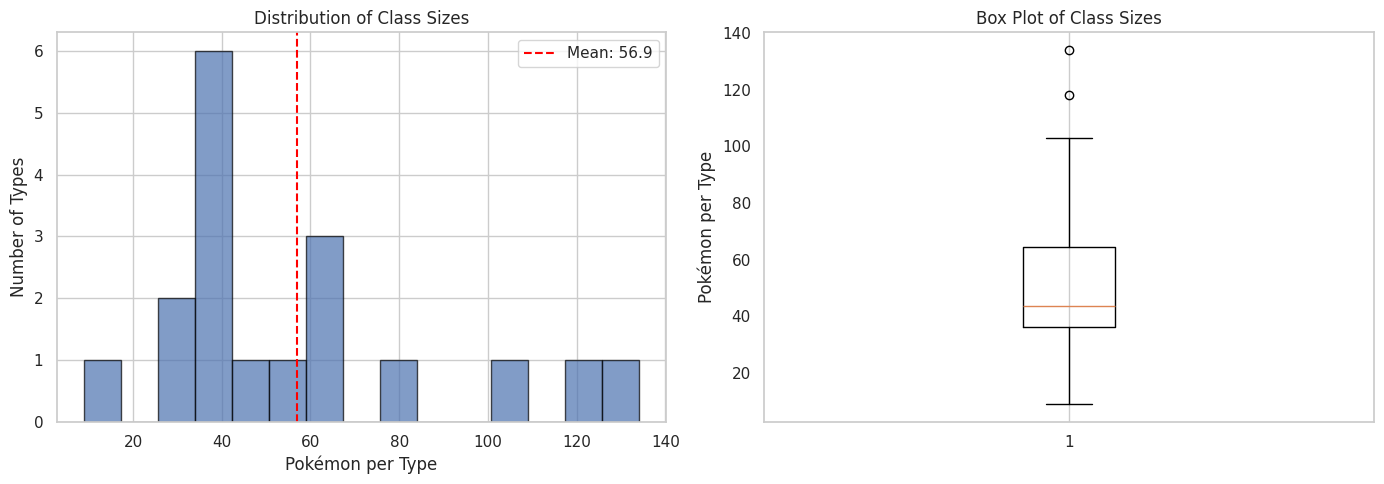

In [6]:
# Class balance analysis
type_dist = df['type1'].value_counts()

print(f"Estadísticas de distribución de clases (type1):")
print(f"  - Media: {type_dist.mean():.2f}")
print(f"  - Desv Est: {type_dist.std():.2f}")
print(f"  - Min: {type_dist.min()} ({type_dist.idxmin()})")
print(f"  - Max: {type_dist.max()} ({type_dist.idxmax()})")
print(f"  - Mediana: {type_dist.median():.2f}")

# Class imbalance ratio
print(f"\nRatio des-balance (Max/Min): {type_dist.max() / type_dist.min():.2f}x")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of class distribution
axes[0].hist(type_dist.values, bins=15, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Pokémon per Type')
axes[0].set_ylabel('Number of Types')
axes[0].set_title('Distribution of Class Sizes')
axes[0].axvline(type_dist.mean(), color='red', linestyle='--', label=f'Mean: {type_dist.mean():.1f}')
axes[0].legend()

# Box plot
axes[1].boxplot(type_dist.values)
axes[1].set_ylabel('Pokémon per Type')
axes[1].set_title('Box Plot of Class Sizes')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

## 4. Dual vs Mono type Pokemon

Tipos puros (mono-type): 499 (48.7%)
Tipos duales (dual-type): 526 (51.3%)


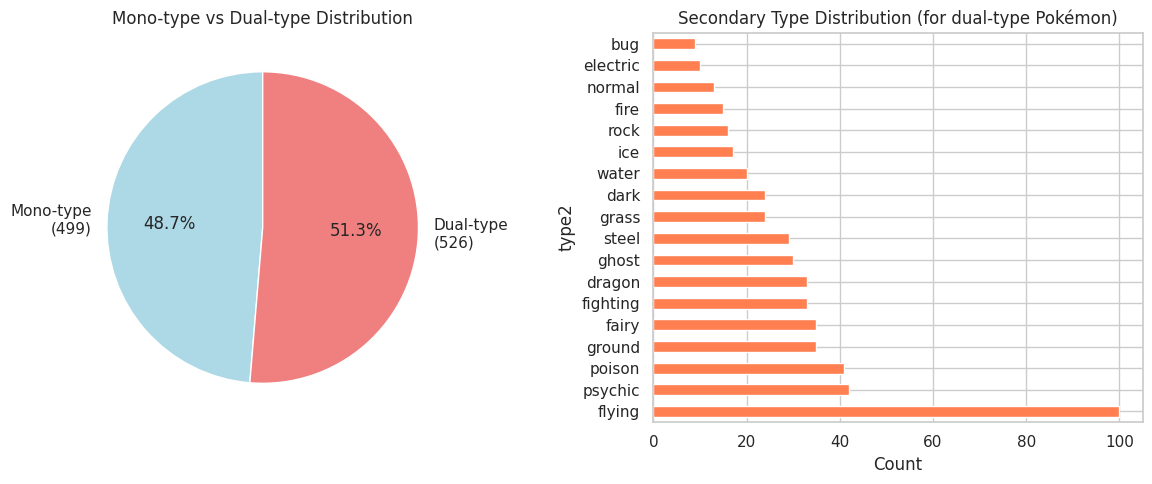

In [7]:
# Mono-type vs Dual-type
monotype = df[df['type2'].isna()]
dualtype = df[df['type2'].notna()]

print(f"Tipos puros (mono-type): {len(monotype)} ({100*len(monotype)/len(df):.1f}%)")
print(f"Tipos duales (dual-type): {len(dualtype)} ({100*len(dualtype)/len(df):.1f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
sizes = [len(monotype), len(dualtype)]
labels = [f'Mono-type\n({len(monotype)})', f'Dual-type\n({len(dualtype)})']
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
axes[0].set_title('Mono-type vs Dual-type Distribution')

# Distribution of secondary types
type2_counts = df[df['type2'].notna()]['type2'].value_counts()
type2_counts.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_xlabel('Count')
axes[1].set_title('Secondary Type Distribution (for dual-type Pokémon)')

plt.tight_layout()
plt.show()

## 5. Resumen de Desafíos para ML

In [8]:
# Summary of challenges
print("""\n╔════════════════════════════════════════════════════════════════╗
║  RESUMEN DE DESAFÍOS PARA ML                                   ║
╚════════════════════════════════════════════════════════════════╝

1. DESBALANCE DE CLASES:\n""")
print(f"   - Tipo más frecuente: {type_dist.idxmax()} ({type_dist.max()} Pokémon)")
print(f"   - Tipo menos frecuente: {type_dist.idxmin()} ({type_dist.min()} Pokémon)")
print(f"   - Ratio: {type_dist.max() / type_dist.min():.1f}x")

print(f"\n2. TIPOS RAROS (< 5 Pokémon por tipo):")
rare_types = type_dist[type_dist < 5]
print(f"   - Cantidad: {len(rare_types)} tipos")
for t, count in rare_types.items():
    print(f"     - {t}: {count}")

print(f"\n3. POKÉMON VOLADORES (Flying type):")
print(f"   - Voladores primarios: {len(flying_primary)}")
print(f"   - Voladores puros: {len(flying_pure)}")
print(f"   - Total con tipo volador: {len(flying_primary) + len(flying_secondary_only)}")
print(f"   ⚠️  Muy pocos para CV estratificada")

print(f"\n4. CONFUSION POTENCIAL (secundarios como primarios):")
confusion_potential = 0
for idx, row in df.iterrows():
    type2 = row['type2']
    if type2 is not None and type2 in df['type1'].values:
        confusion_potential += 1
print(f"   - Pokémon cuyo tipo2 es tipo1 de otros: {confusion_potential}")
print(f"   - Por qué: Proporciona insight XAI natural cuando el modelo predice tipo2\n")


╔════════════════════════════════════════════════════════════════╗
║  RESUMEN DE DESAFÍOS PARA ML                                   ║
╚════════════════════════════════════════════════════════════════╝

1. DESBALANCE DE CLASES:

   - Tipo más frecuente: water (134 Pokémon)
   - Tipo menos frecuente: flying (9 Pokémon)
   - Ratio: 14.9x

2. TIPOS RAROS (< 5 Pokémon por tipo):
   - Cantidad: 0 tipos

3. POKÉMON VOLADORES (Flying type):
   - Voladores primarios: 9
   - Voladores puros: 3
   - Total con tipo volador: 109
   ⚠️  Muy pocos para CV estratificada

4. CONFUSION POTENCIAL (secundarios como primarios):
   - Pokémon cuyo tipo2 es tipo1 de otros: 526
   - Por qué: Proporciona insight XAI natural cuando el modelo predice tipo2



## 6. Propuestas de Estrategia

In [9]:
print("""\n╔════════════════════════════════════════════════════════════════╗
║  OPCIONES RECOMENDADAS PARA PROCEDER                          ║
╚════════════════════════════════════════════════════════════════╝

OPCIÓN A: Subset de tipos frecuentes (más fácil)
─────────────────────────────────────────────
• Seleccionar top 5-10 tipos con ≥ 50 Pokémon cada uno
• Proporciona balance razonable para CV y XAI
• Focus en interpretabilidad

OPCIÓN B: Usar todos los 18 tipos (desafiante pero interesante)
──────────────────────────────────────────────────────────────
• Stratified K-Fold con adjustment para clases pequeñas
• Técnicas de balanceo (oversampling/undersampling)
• El desbalance es realista y demuestra ML real

OPCIÓN C: Dividir por tipos de cartas/rareza (tu sugerencia)
──────────────────────────────────────────────────────────────
• Agrupar tipos en categorías temáticas
• Voladores, Físicos, Especiales, etc.
• Reduce clases y permite CV más limpia

RECOMENDACIÓN PARA VOLADORES:
───────────────────────────────
• Solo 9 voladores es muy poco para validación confiable
• Estrategia actual (mezclarlos en normal/secundario) es pragmática
• O combinar con otros 'raros' para formar una clase 'Other/Rare'
""")


╔════════════════════════════════════════════════════════════════╗
║  OPCIONES RECOMENDADAS PARA PROCEDER                          ║
╚════════════════════════════════════════════════════════════════╝

OPCIÓN A: Subset de tipos frecuentes (más fácil)
─────────────────────────────────────────────
• Seleccionar top 5-10 tipos con ≥ 50 Pokémon cada uno
• Proporciona balance razonable para CV y XAI
• Focus en interpretabilidad

OPCIÓN B: Usar todos los 18 tipos (desafiante pero interesante)
──────────────────────────────────────────────────────────────
• Stratified K-Fold con adjustment para clases pequeñas
• Técnicas de balanceo (oversampling/undersampling)
• El desbalance es realista y demuestra ML real

OPCIÓN C: Dividir por tipos de cartas/rareza (tu sugerencia)
──────────────────────────────────────────────────────────────
• Agrupar tipos en categorías temáticas
• Voladores, Físicos, Especiales, etc.
• Reduce clases y permite CV más limpia

RECOMENDACIÓN PARA VOLADORES:
──────────────

## 7. Estadísticas Detalladas

In [10]:
# Detailed statistics table
stats_df = pd.DataFrame({
    'Type': type_dist.index,
    'Count': type_dist.values,
    'Percentage': (100 * type_dist.values / len(df)).round(2),
    'Log2(Count)': np.log2(type_dist.values).round(2)
})

print("\nDetailed Type Distribution:")
print(stats_df.to_string(index=False))

# Export to CSV for later use
output_path = Path.cwd().parent / 'data' / 'processed' / 'type_distribution.csv'
output_path.parent.mkdir(parents=True, exist_ok=True)
stats_df.to_csv(output_path, index=False)
print(f"\n✓ Exported to: {output_path}")


Detailed Type Distribution:
    Type  Count  Percentage  Log2(Count)
   water    134       13.07         7.07
  normal    118       11.51         6.88
   grass    103       10.05         6.69
     bug     83        8.10         6.38
    fire     66        6.44         6.04
 psychic     60        5.85         5.91
electric     59        5.76         5.88
    rock     58        5.66         5.86
    dark     45        4.39         5.49
  poison     42        4.10         5.39
  ground     40        3.90         5.32
fighting     40        3.90         5.32
  dragon     37        3.61         5.21
   steel     36        3.51         5.17
   ghost     35        3.41         5.13
     ice     31        3.02         4.95
   fairy     29        2.83         4.86
  flying      9        0.88         3.17

✓ Exported to: /home/juandi/Desktop/Master/MLX/mlx/data/processed/type_distribution.csv


In [11]:
# Create a correlation matrix for type combinations
type_combo_matrix = pd.crosstab(df['type1'], df['type2'], margins=True)
print("\nType Combination Matrix (type1 vs type2):")
print(type_combo_matrix.iloc[:10, :10])  # Show top 10x10
print("... (truncated)")


Type Combination Matrix (type1 vs type2):
type2     bug  dark  dragon  electric  fairy  fighting  fire  flying  ghost  \
type1                                                                         
bug         0     1       0         4      2         4     2      13      1   
dark        0     0       4         0      3         2     3       6      1   
dragon      0     1       0         1      0         2     1       4      3   
electric    0     1       3         0      2         2     0       5      1   
fairy       0     0       0         0      0         1     0       3      0   
fighting    0     2       1         1      0         0     0       1      2   
fire        2     1       2         0      0         6     0       6      3   
flying      0     1       2         0      0         1     0       0      0   
ghost       0     1       1         0      2         0     3       2      0   
grass       0     5       5         0      5         3     1       6      5   

type2   

## 8. Distribución de estadísticas

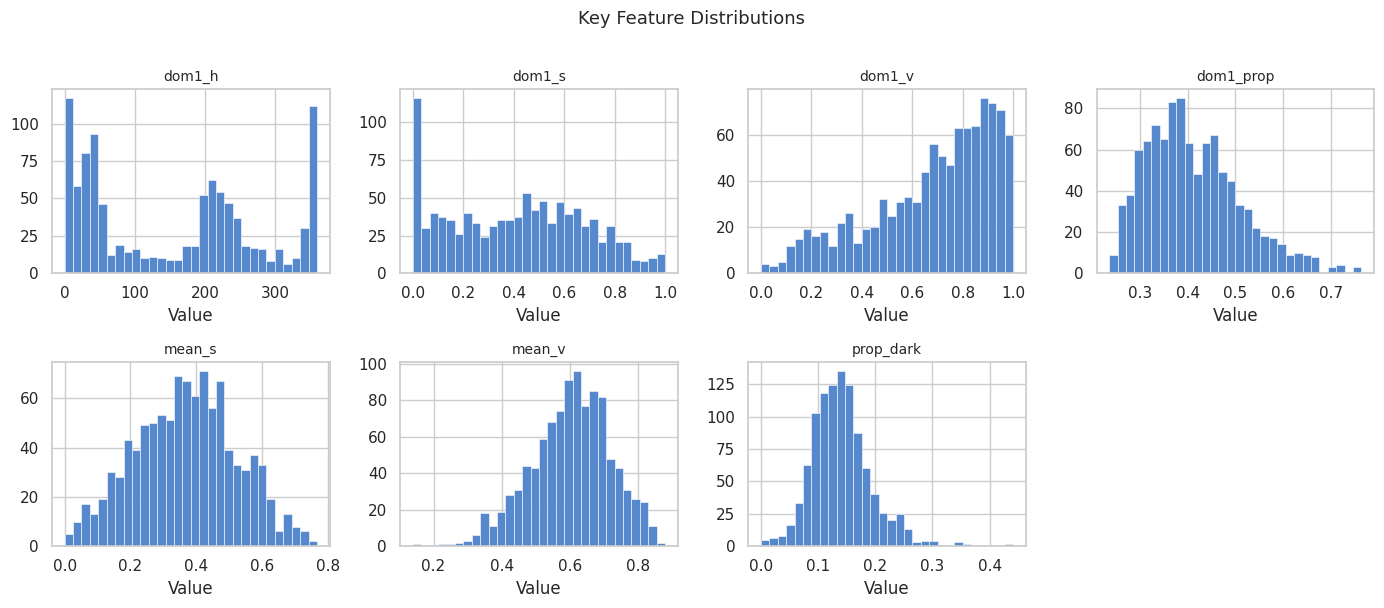

In [12]:
df = common.load_data()
type_to_int, int_to_type = common.get_label_mapping()
feature_cols = common.FEATURE_COLS_ALL

key_features = ["dom1_h", "dom1_s", "dom1_v", "dom1_prop", "mean_s", "mean_v", "prop_dark"]
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    axes[i].hist(df[feat], bins=30, color="#5588cc", edgecolor="white", linewidth=0.4)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel("Value")
axes[-1].set_visible(False)
fig.suptitle("Key Feature Distributions", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

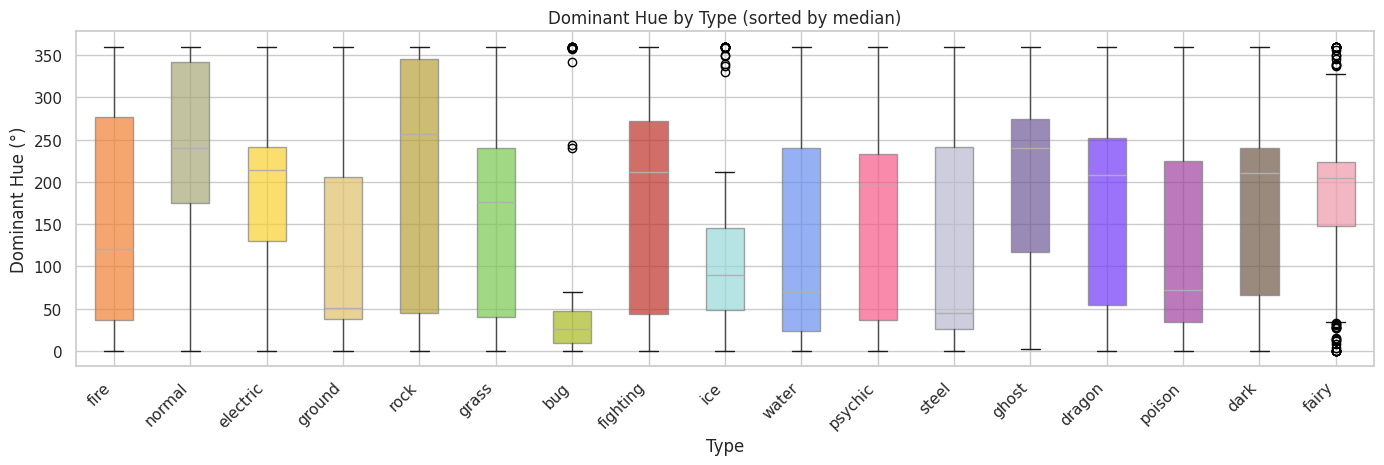

In [13]:
order = df.groupby("type1")["dom1_h"].median().sort_values().index
colors_ordered = [common.TYPE_COLORS.get(t, "#888") for t in order]
fig, ax = plt.subplots(figsize=(14, 5))
bp = df.boxplot(column="dom1_h", by="type1", ax=ax,
                positions=range(len(order)),
                boxprops=dict(color="gray"),
                patch_artist=True,
                return_type="dict")
# color each box
for patch, color in zip(bp["dom1_h"]["boxes"], colors_ordered):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_xlabel("Type")
ax.set_ylabel("Dominant Hue (°)")
ax.set_title("Dominant Hue by Type (sorted by median)")
plt.suptitle("")
plt.tight_layout()
plt.show()

Aunque los boxplots no son muy representativos en el dominio H (al ser circular), nos permiten ver disparidades entre clases. Vemos como el tipo bicho, hielo y eléctrico tienen baja varianza, concentrándose en tonos rojos, azules y amarillos, respectivamente. Otros tipos como el dragón y el siniestro paracen solaparse. Estos deberán diferenciarse por otros canales como el de saturación. 

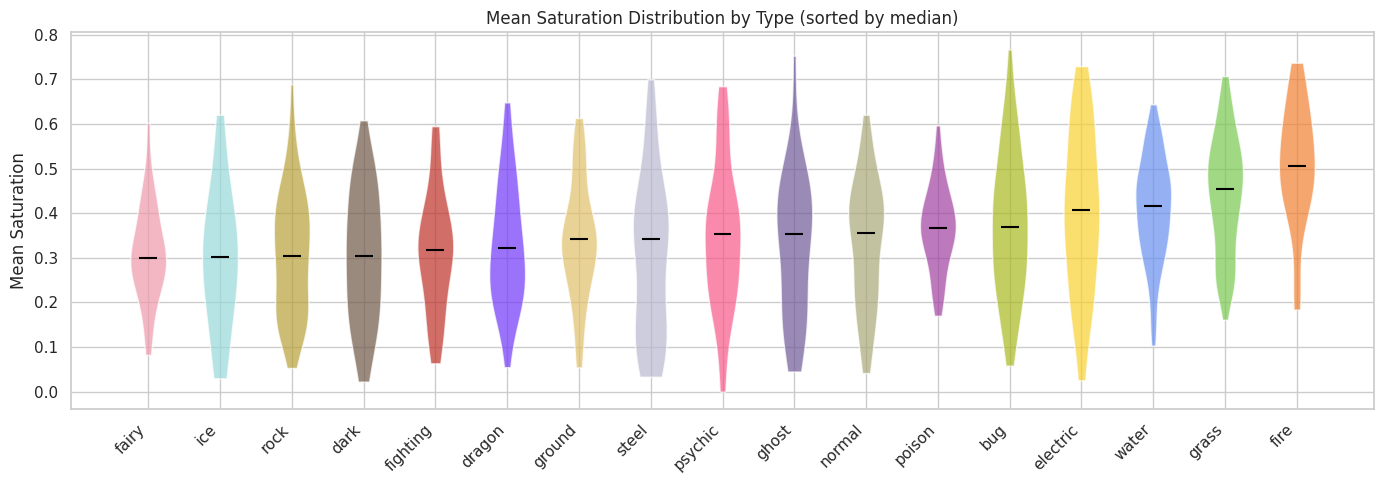

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
order_sat = df.groupby("type1")["mean_s"].median().sort_values().index
parts = ax.violinplot(
    [df[df["type1"] == t]["mean_s"].values for t in order_sat],
    positions=range(len(order_sat)),
    showmedians=True, showextrema=False,
)
for body, color in zip(parts["bodies"],
                       [common.TYPE_COLORS.get(t, "#888") for t in order_sat]):
    body.set_facecolor(color); body.set_alpha(0.7)
parts["cmedians"].set_color("black"); parts["cmedians"].set_linewidth(1.5)
ax.set_xticks(range(len(order_sat)))
ax.set_xticklabels(order_sat, rotation=45, ha="right")
ax.set_ylabel("Mean Saturation")
ax.set_title("Mean Saturation Distribution by Type (sorted by median)")
plt.tight_layout(); plt.show()

Claramente los tipos primarios (fuego, planta, agua y eléctrico) se distinguen por colores muy saturados, mientras que otros con un color menos diferenciable como el hada, hielo, roca o siniestro mantienen niveles de saturación medios bajos.

## 9. Correlación de características

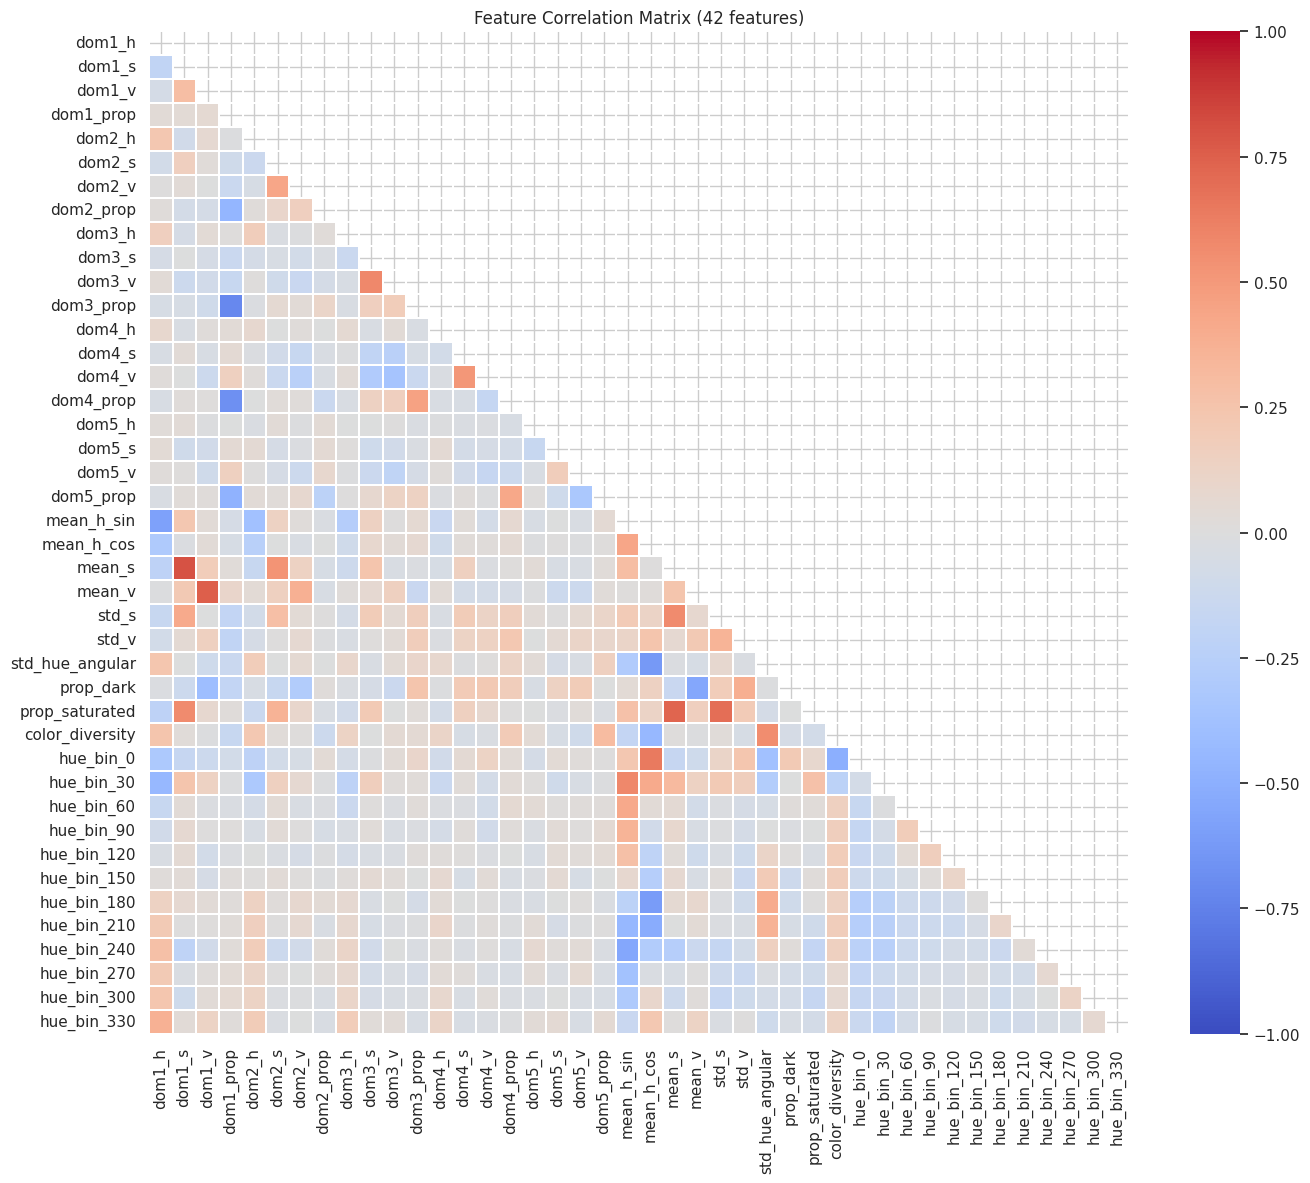

Top 10 correlated feature pairs:
mean_s           dom1_s        0.798167
mean_v           dom1_v        0.756197
prop_saturated   mean_s        0.726990
dom3_prop        dom1_prop     0.711920
prop_saturated   std_s         0.694576
dom4_prop        dom1_prop     0.675904
hue_bin_0        mean_h_cos    0.640802
std_hue_angular  mean_h_cos    0.632541
hue_bin_180      mean_h_cos    0.610211
hue_bin_30       mean_h_sin    0.580235


In [15]:
corr = df[feature_cols].corr()
# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.3,
            xticklabels=feature_cols, yticklabels=feature_cols)
ax.set_title("Feature Correlation Matrix (42 features)")
plt.tight_layout()
plt.show()

corr_abs = corr.abs()
corr_arr = corr_abs.to_numpy().copy()
np.fill_diagonal(corr_arr, 0)
corr_abs_nodiag = pd.DataFrame(corr_arr, index=corr_abs.index, columns=corr_abs.columns)
top_pairs = (corr_abs_nodiag
             .where(np.tril(np.ones(corr_abs_nodiag.shape), k=-1).astype(bool))
             .stack().nlargest(10))
print("Top 10 correlated feature pairs:")
print(top_pairs.to_string())

Como era de esperar, muchos pares de características están fuertemente correlacionados:
 - La saturación media, la proporción de saturación, que son métricas parecidas.
 - La saturación media y la saturación del color primario.
 - Las proporciones de los colores, por estar en una sucesión decreciente.

Para los árboles de decisión, esta redundancia no debe afectar mucho. Para KNN y NN, la regularización o la extracción de características sí pueden verse más afectadas, por lo que tendremos que tenerlo en cuenta.

## 10. Características por tipo

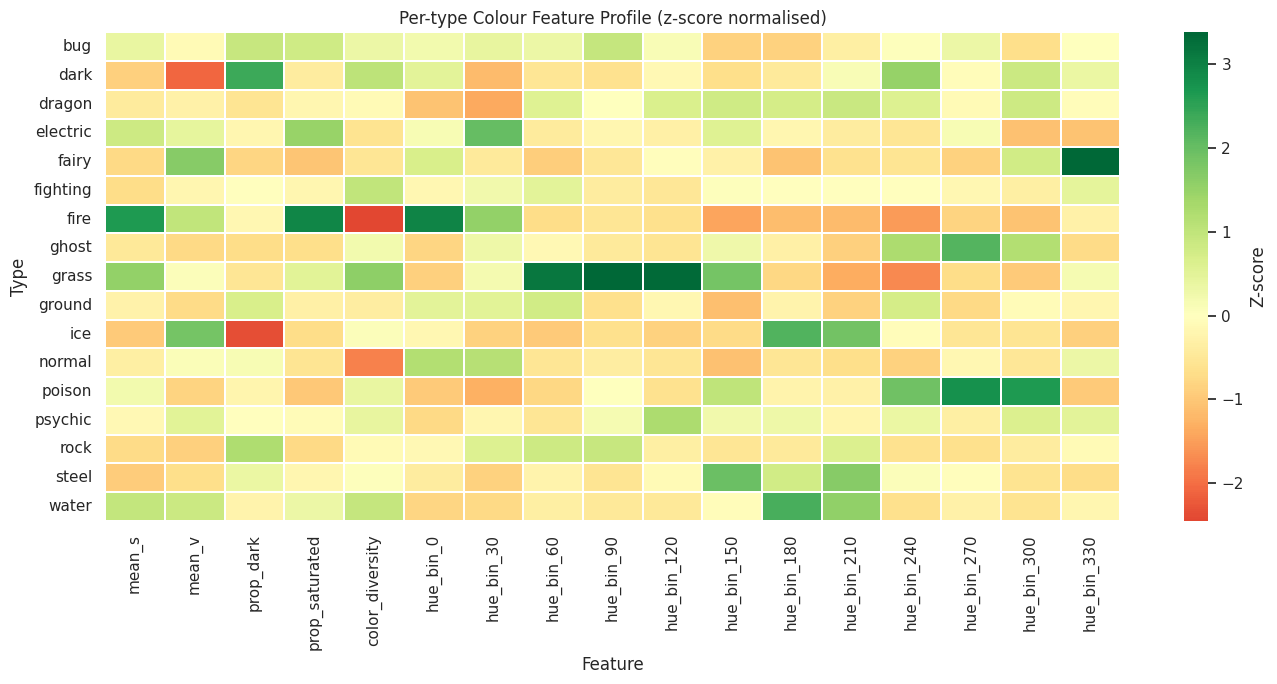

In [16]:
key_feats_profile = [
    "mean_s", "mean_v", "prop_dark", "prop_saturated", "color_diversity",
    "hue_bin_0", "hue_bin_30", "hue_bin_60", "hue_bin_90", "hue_bin_120",
    "hue_bin_150", "hue_bin_180", "hue_bin_210", "hue_bin_240",
    "hue_bin_270", "hue_bin_300", "hue_bin_330",
]
type_profile = df.groupby("type1")[key_feats_profile].mean()
# Z-score per column (across types) to make all features comparable
type_profile_norm = type_profile.copy()
for col in key_feats_profile:
    std_ = type_profile[col].std()
    if std_ > 0:
        type_profile_norm[col] = (type_profile[col] - type_profile[col].mean()) / std_

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(type_profile_norm, cmap="RdYlGn", center=0, ax=ax,
            linewidths=0.3, cbar_kws={"label": "Z-score"})
ax.set_title("Per-type Colour Feature Profile (z-score normalised)")
ax.set_xlabel("Feature"); ax.set_ylabel("Type")
plt.tight_layout(); plt.show()

El mapa de calor del Z-Score de las features ya deja algunas conclusiones clave:
 - Bicho, Dragón, Lucha, Tierra, Psíquico y Roca: ninguna de las características destaca por sobre las demás. Son grupos heterogéneos.
 - Siniestro: destaca un value medio bajo y una alta proporción de colores oscuros.
 - Eléctrico: colores saturados y destacados en el bin 30º-60º (amarillo).
 - Hada: diferenciado por una alta presencia en el bin 330º-360º (rosa-rojo).
 - Fuego: muy diferenciable del resto con colores saturados, poca diversidad de color y presencia en el bin 0º-30º (rojo).
 - Fantasma y veneno: presencia en los bins 240º-330º (morado-rosa).
 - Planta: aglutinado en los bins 60º-150º (verde) y con baja presencia en el 240º-270º (azul).
 - Hielo: muy diferenciable por una baja proporción de colores oscuros y presencia en los bins 180º-240º (azul).
 - Normal: su principal característica es una baja diversidad de colores.
 - Acero y agua: concentrados en los bins 150º-240º (azul). Se diverencian en la saturación y value, bajos para acero y altos para agua.

## 11. Reducción de la dimensionalidad y visualización

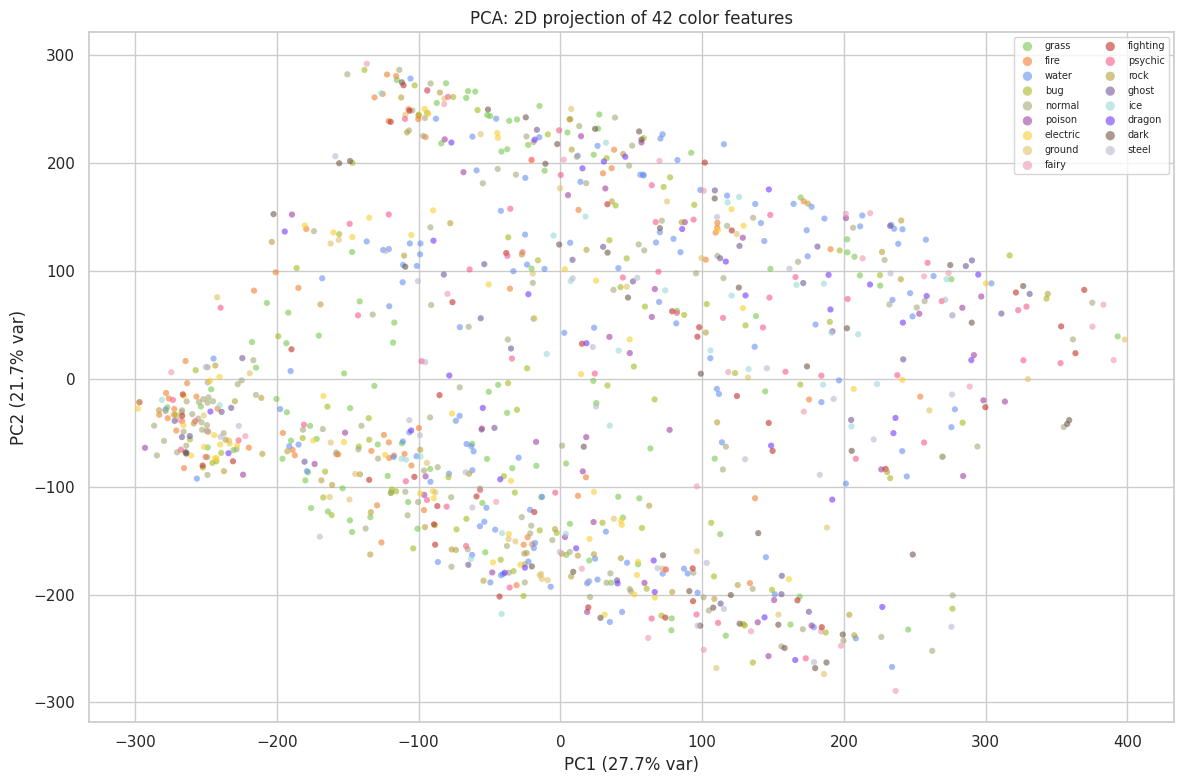

Cumulative explained variance (2 PCs): 49.4%


In [17]:
X = df[feature_cols].values
y = df["type1"].values
y_int = df["type1_encoded"].values

pca = PCA(n_components=2, random_state=common.RANDOM_STATE)
X_pca = pca.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
for type_name in df["type1"].unique():
    mask = y == type_name
    color = common.TYPE_COLORS.get(type_name, "#888888")
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=type_name, alpha=0.6, s=20, edgecolors="none")
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.5)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("PCA: 2D projection of 42 color features")
plt.tight_layout()
plt.show()
print(f"Cumulative explained variance (2 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%")

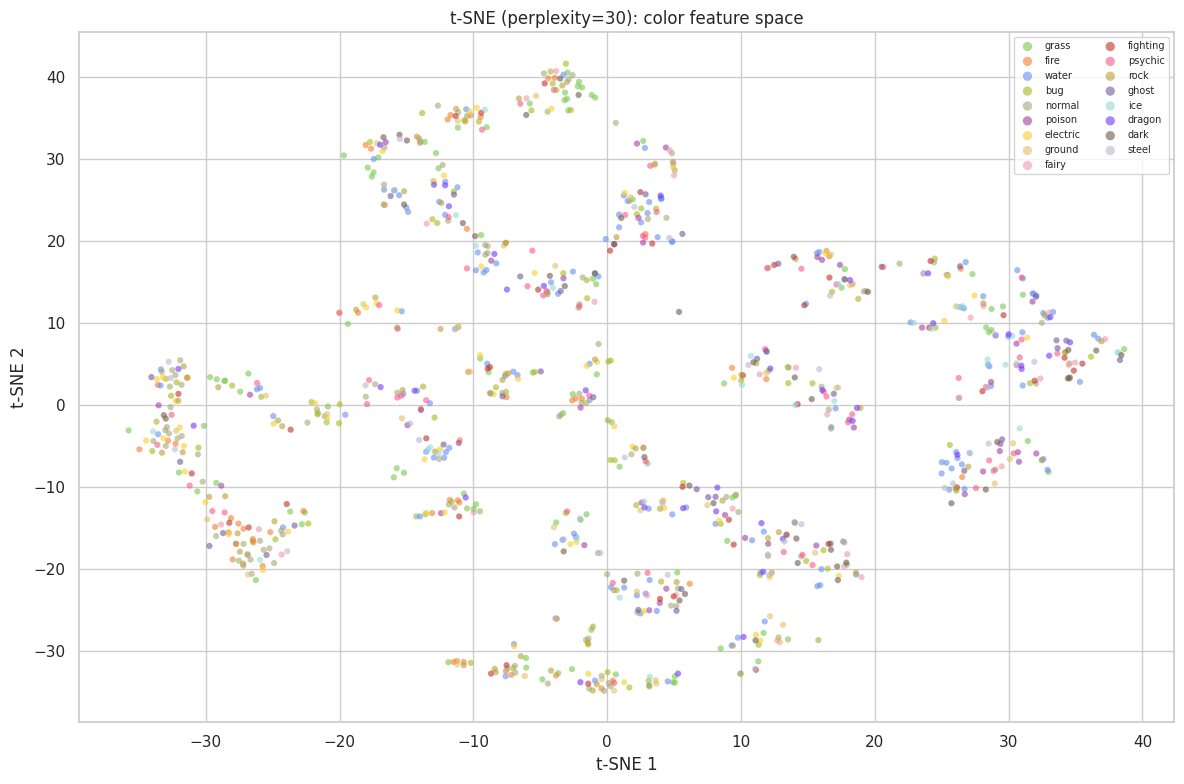

In [18]:
tsne = TSNE(n_components=2, perplexity=30, random_state=common.RANDOM_STATE)
X_tsne = tsne.fit_transform(X)

fig, ax = plt.subplots(figsize=(12, 8))
for type_name in df["type1"].unique():
    mask = y == type_name
    color = common.TYPE_COLORS.get(type_name, "#888888")
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=type_name, alpha=0.6, s=20, edgecolors="none")
ax.legend(loc="upper right", fontsize=7, ncol=2, markerscale=1.5)
ax.set_title("t-SNE (perplexity=30): color feature space")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
plt.tight_layout()
plt.show()